# BioCAS 2023 — Preprocessing Pipeline

Notebook de research para explorar y ejecutar la pipeline de preprocesamiento.

**Flujo:**
1. Cargar config
2. (Opcional) modificar parámetros para experimentar
3. Correr pipeline → obtener `BioCASDataset`
4. Inspeccionar resultados
5. Conectar al training loop

In [1]:
%load_ext autoreload
%autoreload 2

import sys
# sys.path.insert(0, "..")   # ajustar si el notebook está en un subdirectorio

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from pipeline_api import load_config, patch_config, show_config, run_pipeline, load_dataset, save_dataset

## 1 · Cargar configuración

In [2]:
# Config por defecto (lee config/pipeline.yaml)
cfg = load_config()
show_config(cfg)

data:
  raw_wav_dir: data/train/wav
  raw_json_dir: data/train/json
  output_dir: data/processed
  task: 1-2
stages:
  loading:
    enabled: true
  resampling:
    enabled: true
  event_extraction:
    enabled: true
  balanced_sampling:
    enabled: true
  concatenation:
    enabled: true
  padding:
    enabled: true
  augmentation:
    enabled: true
  log_mel:
    enabled: true
  spec_augment:
    enabled: true
  normalization:
    enabled: true
loading:
  target_sr: 4000
  keep_poor_quality: false
event_extraction:
  min_duration_s: 0.2
  keep_unlabelled: false
balanced_sampling:
  strategy: proportional
  target_samples_per_class: null
  random_seed: 42
concatenation:
  min_duration_s: 8.0
  max_duration_s: 8.0
padding:
  mode: reflect
  target_duration_s: 8.0
augmentation:
  spec_augment:
    enabled: true
    freq_mask_param: 27
    time_mask_param: 80
    num_freq_masks: 2
    num_time_masks: 2
    mask_value: 0.0
  time_shift:
    enabled: true
    max_shift_s: 0.5
  add_noise:


In [3]:
cfg_test = load_config(overrides=[
    "data.raw_wav_dir=data/test/wav",
    "data.raw_json_dir=data/test/json",
    "stages.balanced_sampling.enabled=false",
    "stages.augmentation.enabled=false",
    "stages.spec_augment.enabled=false",
])

## 2 · Correr la pipeline completa

In [4]:
import torch
import torchaudio

print(f"Torch version: {torch.__version__}")
print(f"Audio version: {torchaudio.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

Torch version: 2.11.0+cu126
Audio version: 2.11.0+cu126
CUDA disponible: True


In [5]:
# run_pipeline() = build + run + wrap en BioCASDataset
dataset = run_pipeline(cfg)
print(dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/5258 [00:00<?, ?file/s]

  Recordings: 5,028


  extracting events:   0%|          | 0/5028 [00:00<?, ?recording/s]

  Events:     19,863  (valid labels: 19,863)
  Balanced:   19,862  {'CC': 863, 'FC': 3307, 'N': 10506, 'R': 1182, 'S': 662, 'W': 2814, 'WC': 528}

── Fase 2: Procesamiento en 78 chunks de 256 ──


...

  waveform aug:   0%|          | 0/150 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/150 [00:00<?, ?sample/s]

  SpecAugment:   0%|          | 0/150 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/150 [00:00<?, ?sample/s]


── Done: 19,862 samples en 302.9s ──
BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251), mode=in-memory)


In [9]:
save_dataset(dataset, "data/processed_v3/train")

✓ Dataset guardado en 'data\processed_v3\train'


AttributeError: 'BioCASDataset' object has no attribute '_features'

In [10]:
# run_pipeline() = build + run + wrap en BioCASDataset
test_dataset = run_pipeline(cfg_test)
print(test_dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/1309 [00:00<?, ?file/s]

  Recordings: 1,309


  extracting events:   0%|          | 0/1309 [00:00<?, ?recording/s]

  Events:     4,706  (valid labels: 4,706)
  Balanced:   4,706  {'CC': 65, 'FC': 1885, 'N': 2175, 'R': 7, 'S': 8, 'W': 305, 'WC': 261}

── Fase 2: Procesamiento en 19 chunks de 256 ──


...

  concatenation:   0%|          | 0/98 [00:00<?, ?sample/s]

  padding:   0%|          | 0/98 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/98 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/98 [00:00<?, ?sample/s]


── Done: 4,706 samples en 37.6s ──
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=in-memory)


In [11]:
save_dataset(test_dataset, "data/processed_v3/test")

✓ Dataset guardado en 'data\processed_v3\test'


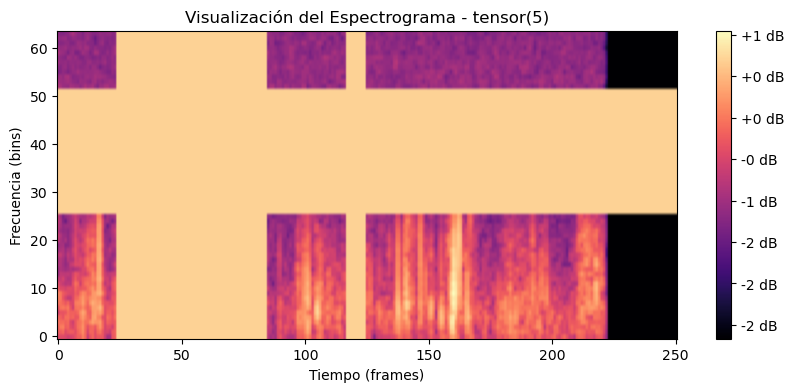

In [14]:
import matplotlib.pyplot as plt

sample, label = dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

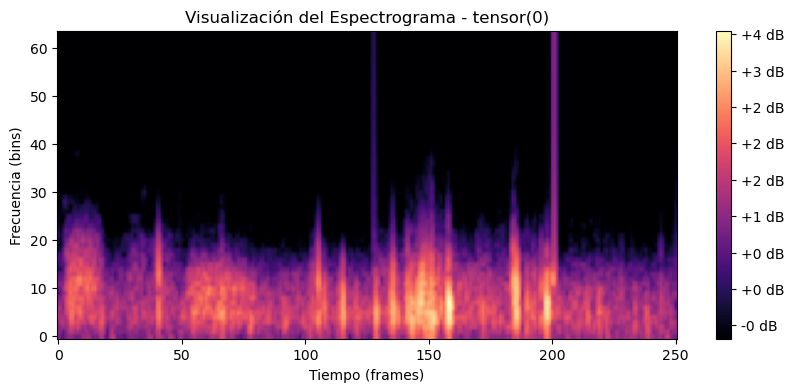

In [15]:
import matplotlib.pyplot as plt

sample, label = test_dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

## Training loop

In [1]:
from pipeline_api import load_dataset

In [2]:
test_dataset = load_dataset("data/processed_v3/test")
train_dataset = load_dataset("data/processed_v3/train")

✓ Dataset cargado desde 'data\processed_v3\test'
  BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
✓ Dataset cargado desde 'data\processed_v3\train'
  BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split



train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
val_loader   = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

# Inspeccionar un batch
features, labels = next(iter(train_loader))
print(f"features : {features.shape}   dtype={features.dtype}")
print(f"labels   : {labels.shape}     dtype={labels.dtype}")
print(f"Pesos para CrossEntropyLoss: {train_dataset.class_weights}")

features : torch.Size([128, 1, 64, 251])   dtype=torch.float32
labels   : torch.Size([128])     dtype=torch.int64
Pesos para CrossEntropyLoss: tensor([0.0154, 0.1373, 0.0577, 0.2451, 0.1880, 0.0491, 0.3073])


In [11]:
from torchsummary import summary

In [12]:
summary(model, input_size=(1, 64, 251))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 32, 32, 126]             288
       BatchNorm2d-2          [-1, 32, 32, 126]              64
              SiLU-3          [-1, 32, 32, 126]               0
            Conv2d-4          [-1, 32, 32, 126]             288
       BatchNorm2d-5          [-1, 32, 32, 126]              64
              SiLU-6          [-1, 32, 32, 126]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12          [-1, 32, 32, 126]               0
           Conv2d-13          [-1, 16, 32, 126]             512
      BatchNorm2d-14          [-1, 16, 

In [14]:
# Ejemplo mínimo de training loop
import torch.nn as nn
from torchvision.models import efficientnet_b0
from tqdm import tqdm
from models.losses import multiclass_focal_loss

N_EPOCHS = 20

model = efficientnet_b0(progress=True)

new_in_channels = 1

# Replace the first convolutional layer
# Original layer: model.features[0][0] (Conv2dNormActivation)
old_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
    new_in_channels,
    old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 7)

model.to("cuda")

#criterion = nn.CrossEntropyLoss(weight=train_dataset.class_weights.to("cuda"))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(N_EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for features, labels in pbar:

        features, labels = features.to("cuda"), labels.to("cuda")
        outputs = model(features)

        loss = multiclass_focal_loss(outputs, labels, alpha=train_dataset.class_weights.to("cuda"))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total  += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        current_acc = 100 * train_correct / train_total 

        pbar.set_description(f"Epoch {epoch+1} [Loss: {loss.item():.4f}]")
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{current_acc:.2f}%"
        })
        pbar.refresh()


    # --- FASE DE TEST / VALIDACIÓN ---
    model.eval()
    val_correct = 0
    val_total = 0
    val_running_loss = 0.0

    with torch.no_grad(): # Desactiva gradientes, ahorra VRAM
        # Usamos val_loader para el test set
        for v_features, v_labels in val_loader:
            v_features, v_labels = v_features.to("cuda"), v_labels.to("cuda")
            
            v_outputs = model(v_features)
            v_loss = multiclass_focal_loss(v_outputs, v_labels, alpha=test_dataset.class_weights.to("cuda"))
            
            val_running_loss += v_loss.item()
            _, v_predicted = torch.max(v_outputs.data, 1)
            val_total += v_labels.size(0)
            val_correct += (v_predicted == v_labels).sum().item()

    # Métricas finales de la época
    epoch_train_acc = 100 * train_correct / train_total
    epoch_val_acc = 100 * val_correct / val_total
    epoch_val_loss = val_running_loss / len(val_loader)

    print(f"RESUMEN EPOCH {epoch+1}: "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Acc: {epoch_val_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}")

print("Dataset listo para training.")
print(f"  Train : {len(train_loader)} muestras")
print(f"  Val   : {len(val_loader)} muestras")
print(f"  Shape : {train_dataset.feature_shape}  (C, n_mels, T)")
print(f"  Clases: {train_dataset.num_classes}")

Epoch 1 [Loss: 0.0419]: 100%|██████████| 156/156 [12:19<00:00,  4.74s/it, loss=0.0419, acc=27.95%]


RESUMEN EPOCH 1: Train Acc: 27.95% | Val Acc: 30.45% | Val Loss: 0.0112


Epoch 2 [Loss: 0.0207]: 100%|██████████| 156/156 [12:21<00:00,  4.75s/it, loss=0.0207, acc=41.63%]


RESUMEN EPOCH 2: Train Acc: 41.63% | Val Acc: 41.18% | Val Loss: 0.0129


Epoch 3 [Loss: 0.0311]: 100%|██████████| 156/156 [12:46<00:00,  4.91s/it, loss=0.0311, acc=46.18%]


...

RESUMEN EPOCH 18: Train Acc: 79.37% | Val Acc: 25.54% | Val Loss: 0.0112


Epoch 19 [Loss: 0.0145]: 100%|██████████| 156/156 [02:38<00:00,  1.02s/it, loss=0.0145, acc=80.15%]


RESUMEN EPOCH 19: Train Acc: 80.15% | Val Acc: 40.69% | Val Loss: 0.0127


Epoch 20 [Loss: 0.0104]: 100%|██████████| 156/156 [02:40<00:00,  1.03s/it, loss=0.0104, acc=80.89%]


RESUMEN EPOCH 20: Train Acc: 80.89% | Val Acc: 30.66% | Val Loss: 0.0109
Dataset listo para training.
  Train : 156 muestras
  Val   : 37 muestras
  Shape : (1, 64, 251)  (C, n_mels, T)
  Clases: 7


In [15]:
for epoch in range(N_EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for features, labels in pbar:

        features, labels = features.to("cuda"), labels.to("cuda")
        outputs = model(features)

        loss = multiclass_focal_loss(outputs, labels, alpha=train_dataset.class_weights.to("cuda"))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total  += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        current_acc = 100 * train_correct / train_total 

        pbar.set_description(f"Epoch {epoch+1} [Loss: {loss.item():.4f}]")
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{current_acc:.2f}%"
        })
        pbar.refresh()


    # --- FASE DE TEST / VALIDACIÓN ---
    model.eval()
    val_correct = 0
    val_total = 0
    val_running_loss = 0.0

    with torch.no_grad(): # Desactiva gradientes, ahorra VRAM
        # Usamos val_loader para el test set
        for v_features, v_labels in val_loader:
            v_features, v_labels = v_features.to("cuda"), v_labels.to("cuda")
            
            v_outputs = model(v_features)
            v_loss = multiclass_focal_loss(v_outputs, v_labels, alpha=test_dataset.class_weights.to("cuda"))
            
            val_running_loss += v_loss.item()
            _, v_predicted = torch.max(v_outputs.data, 1)
            val_total += v_labels.size(0)
            val_correct += (v_predicted == v_labels).sum().item()

    # Métricas finales de la época
    epoch_train_acc = 100 * train_correct / train_total
    epoch_val_acc = 100 * val_correct / val_total
    epoch_val_loss = val_running_loss / len(val_loader)

    print(f"RESUMEN EPOCH {epoch+1}: "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Acc: {epoch_val_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}")

print("Dataset listo para training.")
print(f"  Train : {len(train_loader)} muestras")
print(f"  Val   : {len(val_loader)} muestras")
print(f"  Shape : {train_dataset.feature_shape}  (C, n_mels, T)")
print(f"  Clases: {train_dataset.num_classes}")

Epoch 1 [Loss: 0.0041]: 100%|██████████| 156/156 [01:45<00:00,  1.48it/s, loss=0.0041, acc=81.20%]


RESUMEN EPOCH 1: Train Acc: 81.20% | Val Acc: 26.41% | Val Loss: 0.0120


Epoch 2 [Loss: 0.0125]: 100%|██████████| 156/156 [01:35<00:00,  1.63it/s, loss=0.0125, acc=81.55%]


RESUMEN EPOCH 2: Train Acc: 81.55% | Val Acc: 19.93% | Val Loss: 0.0116


Epoch 3 [Loss: 0.0037]: 100%|██████████| 156/156 [01:34<00:00,  1.66it/s, loss=0.0037, acc=82.02%]


...

RESUMEN EPOCH 18: Train Acc: 86.73% | Val Acc: 29.71% | Val Loss: 0.0156


Epoch 19 [Loss: 0.0044]: 100%|██████████| 156/156 [02:28<00:00,  1.05it/s, loss=0.0044, acc=85.89%]


RESUMEN EPOCH 19: Train Acc: 85.89% | Val Acc: 19.44% | Val Loss: 0.0153


Epoch 20 [Loss: 0.0017]: 100%|██████████| 156/156 [03:35<00:00,  1.38s/it, loss=0.0017, acc=86.77%]


RESUMEN EPOCH 20: Train Acc: 86.77% | Val Acc: 8.67% | Val Loss: 0.0182
Dataset listo para training.
  Train : 156 muestras
  Val   : 37 muestras
  Shape : (1, 64, 251)  (C, n_mels, T)
  Clases: 7
